# FlexZBoost photo-z for the Y4 baseline v5.3 / desi depth

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np

import qp
import tables_io

from rail.core.data import TableHandle
from rail.core.stage import RailStage

%matplotlib inline 

In [2]:
def plot_and_stats(zspec,zphot):
    
    z_spec = np.copy(zspec)
    z_phot=np.copy(zphot)
    x = np.arange(0,5.4,0.05)

    # define differences of >0.15*(1+z) as non-Gaussian 'outliers'    
    outlier_upper = x + 0.15*(1+x)
    outlier_lower = x - 0.15*(1+x)

    mask = np.abs((z_phot - z_spec)/(1 + z_spec)) > 0.15
    notmask = ~mask 
    
    #Standard Deviation of the predicted redshifts compared to the data:
    std_result = np.std((z_phot - z_spec)/(1 + z_spec), ddof=1)

    #Normalized MAD (Median Absolute Deviation):
    nmad = 1.48 * np.median(np.abs((z_phot - z_spec)/(1 + z_spec)))

    #Percentage of delta-z > 0.15(1+z) outliers:
    eta = np.sum(np.abs((z_phot - z_spec)/(1 + z_spec)) > 0.15)/len(z_spec)
    
    #Median offset (normalized by (1+z); i.e., bias:
    bias = np.median(((z_phot - z_spec)/(1 + z_spec)))
    sigbias=std_result/np.sqrt(0.64*len(z_phot))
    
    # make photo-z/spec-z plot
    plt.figure(figsize=(8, 8))
    
    #add lines to indicate outliers
    plt.plot(x, outlier_upper, 'k--')
    plt.plot(x, outlier_lower, 'k--')
    plt.plot(z_spec[mask], z_phot[mask], 'r.', markersize=6,  alpha=0.05)
    plt.plot(z_spec[notmask], z_phot[notmask], 'b.',  markersize=6, alpha=0.05)
    plt.plot(x, x, linewidth=1.5, color = 'red')
    plt.title('$\sigma_\mathrm{NMAD} \ = $%6.4f\n'%nmad+'$(\Delta z)>0.15(1+z) $ outliers = %6.3f'%(eta*100)+'%', fontsize=18)
    plt.xlim([0.0, 2])
    plt.ylim([0.0, 2])
    plt.xlabel('$z_{\mathrm{spec}}$', fontsize = 27)
    plt.ylabel('$z_{\mathrm{photo}}$', fontsize = 27)
    plt.grid(alpha = 0.8)
    plt.tick_params(labelsize=15)
    plt.show()
    

<>:36: SyntaxWarning: invalid escape sequence '\s'
<>:36: SyntaxWarning: invalid escape sequence '\D'
<>:39: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\s'
<>:36: SyntaxWarning: invalid escape sequence '\D'
<>:39: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
/var/folders/f0/8g1vfmvd7h500d1s0b9m35_h0000gn/T/ipykernel_32255/3777923599.py:36: SyntaxWarning: invalid escape sequence '\s'
  plt.title('$\sigma_\mathrm{NMAD} \ = $%6.4f\n'%nmad+'$(\Delta z)>0.15(1+z) $ outliers = %6.3f'%(eta*100)+'%', fontsize=18)
/var/folders/f0/8g1vfmvd7h500d1s0b9m35_h0000gn/T/ipykernel_32255/3777923599.py:36: SyntaxWarning: invalid escape sequence '\D'
  plt.title('$\sigma_\mathrm{NMAD} \ = $%6.4f\n'%nmad+'$(\Delta z)>0.15(1+z) $ outliers = %6.3f'%(eta*100)+'%', fontsize=18)
/var/folders/f0/8g1vfmvd7h500d1s0b9m35_h0000gn/T/ipykernel_32255/3777923599.py:39: Synta

Create references to the training and test data.

In [3]:
from collections import OrderedDict
def pandas_to_order_dict(df, columns):
    ordered_dict = OrderedDict({col: df[col].to_numpy() for col in columns})
    return ordered_dict

In [4]:
# load files:
import pandas as pd

samples = []
for label in ['y4desi_deep','y4desi_rest','y4baseline']:
    fname = f"cardinal_train_100k-{label}.parquet"
    samples.append(pd.read_parquet(fname))

In [5]:
samples2 = []
for label in ['y4desi_deep','y4desi_rest','y4baseline']:
    fname = f"cardinal_test_100k-{label}.parquet"
    samples2.append(pd.read_parquet(fname))

Define the configurations for the ML model to be trained by Flexcode. Specifically we'll use Xgboost with a set of 35 cosine basis functions.

In [ ]:
fz_dict = dict(zmin=0.0, zmax=3.0, nzbins=301,
               trainfrac=0.75, bumpmin=0.02, bumpmax=0.35,
               nbump=20, sharpmin=0.7, sharpmax=2.1, nsharp=15,
               max_basis=35, basis_system='cosine',  
               hdf5_groupname='',
               regression_params={'max_depth': 8,'objective':'reg:squarederror'},
               bands = ["mag_u_lsst", "mag_g_lsst","mag_r_lsst","mag_i_lsst","mag_z_lsst","mag_y_lsst"],
              err_bands = ["mag_u_lsst_err", "mag_g_lsst_err","mag_r_lsst_err","mag_i_lsst_err","mag_z_lsst_err","mag_y_lsst_err"],
              ref_band = "mag_i_lsst")

fz_modelfile = 'demo_FZB_model.pkl'

Define the RAIL stage to train the model

In [7]:
from rail.estimation.algos.flexzboost import FlexZBoostInformer, FlexZBoostEstimator

In [8]:
inform_pzflex = FlexZBoostInformer.make_stage(name='inform_fzboost', model=fz_modelfile, **fz_dict)

Then we'll run that stage to train the model and store the result in a file name `demo_FZB_model.pkl`.

In [9]:
#%%time
columns = ["mag_u_lsst", "mag_g_lsst","mag_r_lsst","mag_i_lsst","mag_z_lsst","mag_y_lsst",
           "mag_u_lsst_err", "mag_g_lsst_err","mag_r_lsst_err","mag_i_lsst_err","mag_z_lsst_err","mag_y_lsst_err",
          "redshift"]
data = pandas_to_order_dict(samples[0], columns)
data = {k: np.array(v, copy=True) for k, v in data.items()}
inform_pzflex.inform(data)

Inserting handle into data store.  input: None, inform_fzboost
stacking some data...
read in training data
fit the model...


/Users/qhang/anaconda3/envs/rail_dev/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [14:18:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/qhang/anaconda3/envs/rail_dev/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [14:18:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/qhang/anaconda3/envs/rail_dev/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [14:18:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/qhang/anaconda3/envs/rail_dev/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [14:18:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are

finding best bump thresh...
finding best sharpen parameter...
Retraining with full training set...


/Users/qhang/anaconda3/envs/rail_dev/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [14:21:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/qhang/anaconda3/envs/rail_dev/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [14:21:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/qhang/anaconda3/envs/rail_dev/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [14:21:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/qhang/anaconda3/envs/rail_dev/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [14:21:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are

Best bump = 0.10684210526315789, best sharpen = 1.4
Inserting handle into data store.  model_inform_fzboost: inprogress_demo_FZB_model.pkl, inform_fzboost


Now we configure the RAIL stage that will evaluate test data using the saved model.
Note that we specify `qp_representation='flexzboost'` here to instruct `rail_flexzboost` to store the model weights using `qp_flexzboost`.

In [20]:
pzflex_qp_flexzboost = FlexZBoostEstimator.make_stage(name='fzboost_flexzboost', hdf5_groupname='',
                            model=inform_pzflex.get_handle('model'),
                            output='flexzboost.hdf5',
                            qp_representation='flexzboost',
                            bands = ["mag_u_lsst", "mag_g_lsst","mag_r_lsst","mag_i_lsst","mag_z_lsst","mag_y_lsst"],
              err_bands = ["mag_u_lsst_err", "mag_g_lsst_err","mag_r_lsst_err","mag_i_lsst_err","mag_z_lsst_err","mag_y_lsst_err"],
              ref_band = "mag_i_lsst")

In [21]:
columns = ["mag_u_lsst", "mag_g_lsst","mag_r_lsst","mag_i_lsst","mag_z_lsst","mag_y_lsst",
           "mag_u_lsst_err", "mag_g_lsst_err","mag_r_lsst_err","mag_i_lsst_err","mag_z_lsst_err","mag_y_lsst_err",
          "redshift"]
data = pandas_to_order_dict(samples2[0], columns)
data = {k: np.array(v, copy=True) for k, v in data.items()}

Now we actually evaluate the test data, 20,449 example galaxies, using the trained model, and then print out the size of the file that was saved. 

Note that the final output size will depend on the number of basis functions used by the model. Again, for this experiment, we used 35 basis functions.

In [22]:
#%%time
output_file_name = './flexzboost.hdf5'
try:
    os.unlink(output_file_name)
except FileNotFoundError:
    pass

fzresults_qp_flexzboost = pzflex_qp_flexzboost.estimate(data)
file_size = os.path.getsize(output_file_name)
print("File Size is :", file_size, "bytes")

Inserting handle into data store.  input: None, fzboost_flexzboost
Inserting handle into data store.  model_inform_fzboost: <class 'rail.core.data.ModelHandle'> demo_FZB_model.pkl, (wd), fzboost_flexzboost
Process 0 running estimator on chunk 0 - 74,883
Process 0 estimating PZ PDF for rows 0 - 74,883
Inserting handle into data store.  output_fzboost_flexzboost: inprogress_flexzboost.hdf5, fzboost_flexzboost
File Size is : 7197960 bytes


Example calculating median and mode. Note that we're using the `%%timeit` magic command to get an estimate of the time required for calculating `median`, but we're using `%%time` to estimate the `mode`. This is because `qp` will cache the output of the `pdf` function for a given grid. If we used `%%timeit`, then the resulting estimate would average the run time of one non-cached calculation and N-1 cached calculations. 

In [14]:
zgrid = np.linspace(0, 3., 301)

In [23]:
#%%time
fz_medians_qp_flexzboost = fzresults_qp_flexzboost().median()

In [15]:
#%%time
fz_modes_qp_flexzboost = fzresults_qp_flexzboost().mode(grid=zgrid)

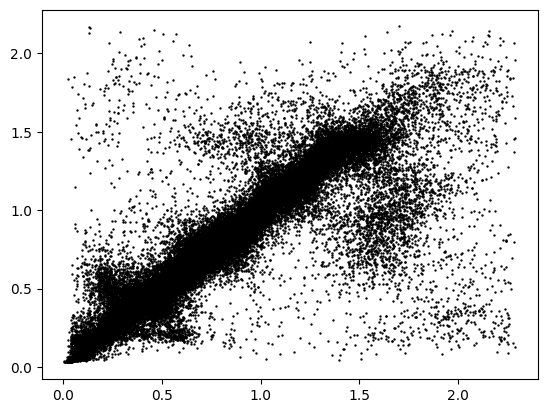

In [24]:
plt.scatter(data['redshift'], fz_medians_qp_flexzboost, color='k', s=0.5)

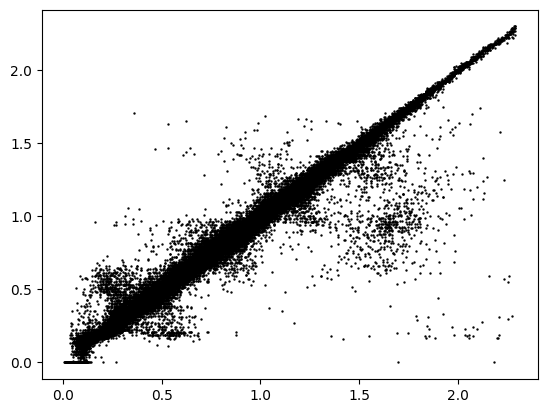

In [17]:
plt.scatter(data['redshift'], fz_modes_qp_flexzboost, color='k', s=0.5)

Plotting median values.

Text(0, 0.5, 'Number')

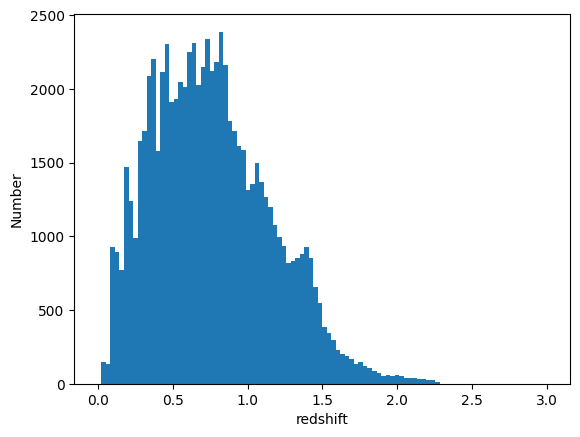

In [27]:
fz_medians_qp_flexzboost = fzresults_qp_flexzboost().median()

plt.hist(fz_medians_qp_flexzboost, bins=np.linspace(-.005,3.005,101));
plt.xlabel("redshift")
plt.ylabel("Number")

In [29]:
# train the other two models:
fz_dict = dict(zmin=0.0, zmax=3.0, nzbins=301,
               trainfrac=0.75, bumpmin=0.02, bumpmax=0.35,
               nbump=20, sharpmin=0.7, sharpmax=2.1, nsharp=15,
               max_basis=35, basis_system='cosine',
               hdf5_groupname='',
               regression_params={'max_depth': 8,'objective':'reg:squarederror'},
               bands = ["mag_u_lsst", "mag_g_lsst","mag_r_lsst","mag_i_lsst","mag_z_lsst","mag_y_lsst"],
              err_bands = ["mag_u_lsst_err", "mag_g_lsst_err","mag_r_lsst_err","mag_i_lsst_err","mag_z_lsst_err","mag_y_lsst_err"],
              ref_band = "mag_i_lsst")

fz_modelfile = 'demo_FZB_model_rest.pkl'
inform_pzflex = FlexZBoostInformer.make_stage(name='inform_fzboost', model=fz_modelfile, **fz_dict)

In [30]:
columns = ["mag_u_lsst", "mag_g_lsst","mag_r_lsst","mag_i_lsst","mag_z_lsst","mag_y_lsst",
           "mag_u_lsst_err", "mag_g_lsst_err","mag_r_lsst_err","mag_i_lsst_err","mag_z_lsst_err","mag_y_lsst_err",
          "redshift"]
data = pandas_to_order_dict(samples[1], columns)
data = {k: np.array(v, copy=True) for k, v in data.items()}
inform_pzflex.inform(data)

Inserting handle into data store.  input: None, inform_fzboost
stacking some data...
read in training data
fit the model...


/Users/qhang/anaconda3/envs/rail_dev/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:34:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/qhang/anaconda3/envs/rail_dev/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:34:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/qhang/anaconda3/envs/rail_dev/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:34:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/qhang/anaconda3/envs/rail_dev/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:34:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are

finding best bump thresh...
finding best sharpen parameter...
Retraining with full training set...


/Users/qhang/anaconda3/envs/rail_dev/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:37:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/qhang/anaconda3/envs/rail_dev/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:37:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/qhang/anaconda3/envs/rail_dev/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:37:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/qhang/anaconda3/envs/rail_dev/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:37:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are

Best bump = 0.05473684210526315, best sharpen = 1.1
Inserting handle into data store.  model_inform_fzboost: inprogress_demo_FZB_model_rest.pkl, inform_fzboost


In [31]:
pzflex_qp_flexzboost = FlexZBoostEstimator.make_stage(name='fzboost_flexzboost', hdf5_groupname='',
                            model=inform_pzflex.get_handle('model'),
                            output='flexzboost_rest.hdf5',
                            qp_representation='flexzboost',
                            bands = ["mag_u_lsst", "mag_g_lsst","mag_r_lsst","mag_i_lsst","mag_z_lsst","mag_y_lsst"],
              err_bands = ["mag_u_lsst_err", "mag_g_lsst_err","mag_r_lsst_err","mag_i_lsst_err","mag_z_lsst_err","mag_y_lsst_err"],
              ref_band = "mag_i_lsst")
fzresults_qp_flexzboost = pzflex_qp_flexzboost.estimate(data)


Inserting handle into data store.  input: None, fzboost_flexzboost
Inserting handle into data store.  model_inform_fzboost: <class 'rail.core.data.ModelHandle'> demo_FZB_model_rest.pkl, (wd), fzboost_flexzboost
Process 0 running estimator on chunk 0 - 72,948
Process 0 estimating PZ PDF for rows 0 - 72,948
Inserting handle into data store.  output_fzboost_flexzboost: inprogress_flexzboost_rest.hdf5, fzboost_flexzboost


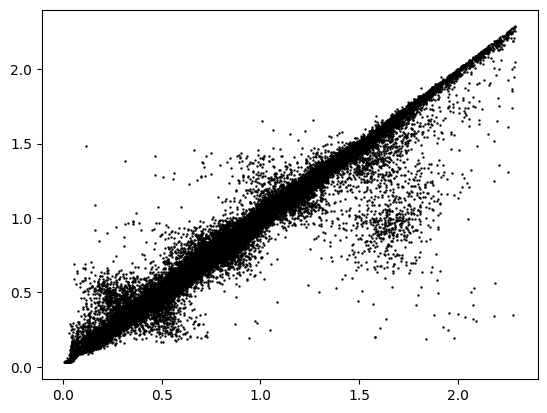

In [32]:
fz_medians_qp_flexzboost = fzresults_qp_flexzboost().median()

plt.scatter(data['redshift'], fz_medians_qp_flexzboost, color='k', s=0.5)

In [33]:
# train the other two models:
fz_dict = dict(zmin=0.0, zmax=3.0, nzbins=301,
               trainfrac=0.75, bumpmin=0.02, bumpmax=0.35,
               nbump=20, sharpmin=0.7, sharpmax=2.1, nsharp=15,
               max_basis=35, basis_system='cosine',
               hdf5_groupname='',
               regression_params={'max_depth': 8,'objective':'reg:squarederror'},
               bands = ["mag_u_lsst", "mag_g_lsst","mag_r_lsst","mag_i_lsst","mag_z_lsst","mag_y_lsst"],
              err_bands = ["mag_u_lsst_err", "mag_g_lsst_err","mag_r_lsst_err","mag_i_lsst_err","mag_z_lsst_err","mag_y_lsst_err"],
              ref_band = "mag_i_lsst")

fz_modelfile = 'demo_FZB_model_baseline.pkl'
inform_pzflex = FlexZBoostInformer.make_stage(name='inform_fzboost', model=fz_modelfile, **fz_dict)

In [34]:
columns = ["mag_u_lsst", "mag_g_lsst","mag_r_lsst","mag_i_lsst","mag_z_lsst","mag_y_lsst",
           "mag_u_lsst_err", "mag_g_lsst_err","mag_r_lsst_err","mag_i_lsst_err","mag_z_lsst_err","mag_y_lsst_err",
          "redshift"]
data = pandas_to_order_dict(samples[2], columns)
data = {k: np.array(v, copy=True) for k, v in data.items()}
inform_pzflex.inform(data)

Inserting handle into data store.  input: None, inform_fzboost
stacking some data...
read in training data
fit the model...


/Users/qhang/anaconda3/envs/rail_dev/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [10:25:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/qhang/anaconda3/envs/rail_dev/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [10:25:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/qhang/anaconda3/envs/rail_dev/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [10:25:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/qhang/anaconda3/envs/rail_dev/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [10:25:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are

finding best bump thresh...
finding best sharpen parameter...
Retraining with full training set...


/Users/qhang/anaconda3/envs/rail_dev/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [10:29:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/qhang/anaconda3/envs/rail_dev/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [10:29:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/qhang/anaconda3/envs/rail_dev/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [10:29:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/qhang/anaconda3/envs/rail_dev/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [10:29:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are

Best bump = 0.05473684210526315, best sharpen = 1.2
Inserting handle into data store.  model_inform_fzboost: inprogress_demo_FZB_model_baseline.pkl, inform_fzboost


In [ ]:
pzflex_qp_flexzboost = FlexZBoostEstimator.make_stage(name='fzboost_flexzboost', hdf5_groupname='',
                            model=inform_pzflex.get_handle('model'),
                            output='flexzboost_baseline.hdf5',
                            qp_representation='flexzboost',
                            bands = ["mag_u_lsst", "mag_g_lsst","mag_r_lsst","mag_i_lsst","mag_z_lsst","mag_y_lsst"],
              err_bands = ["mag_u_lsst_err", "mag_g_lsst_err","mag_r_lsst_err","mag_i_lsst_err","mag_z_lsst_err","mag_y_lsst_err"],
              ref_band = "mag_i_lsst")
fzresults_qp_flexzboost = pzflex_qp_flexzboost.estimate(data)

Inserting handle into data store.  input: None, fzboost_flexzboost
Inserting handle into data store.  model_inform_fzboost: <class 'rail.core.data.ModelHandle'> demo_FZB_model_baseline.pkl, (wd), fzboost_flexzboost
Process 0 running estimator on chunk 0 - 72,899
Process 0 estimating PZ PDF for rows 0 - 72,899
Inserting handle into data store.  output_fzboost_flexzboost: inprogress_flexzboost_baseline.hdf5, fzboost_flexzboost


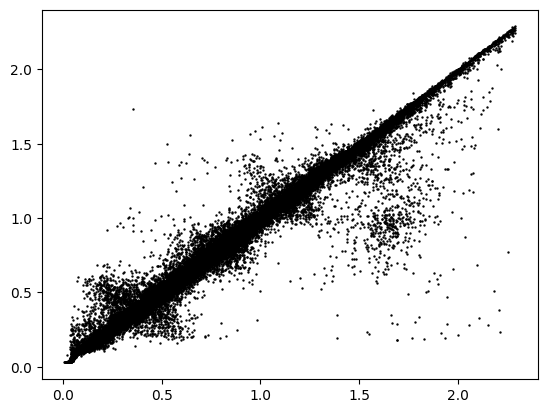

In [36]:
fz_medians_qp_flexzboost = fzresults_qp_flexzboost().median()

plt.scatter(data['redshift'], fz_medians_qp_flexzboost, color='k', s=0.5)

# run on test sample

In [36]:
columns = ["mag_u_lsst", "mag_g_lsst","mag_r_lsst","mag_i_lsst","mag_z_lsst","mag_y_lsst",
           "mag_u_lsst_err", "mag_g_lsst_err","mag_r_lsst_err","mag_i_lsst_err","mag_z_lsst_err","mag_y_lsst_err",
          "redshift"]
data = pandas_to_order_dict(samples[2], columns)
data = {k: np.array(v, copy=True) for k, v in data.items()}

In [37]:
pzflex_qp_flexzboost = FlexZBoostEstimator.make_stage(name='fzboost_flexzboost', hdf5_groupname='',
                            model="demo_FZB_model_baseline.pkl",
                            output='flexzboost_baseline.hdf5',
                            qp_representation='flexzboost',
                            bands = ["mag_u_lsst", "mag_g_lsst","mag_r_lsst","mag_i_lsst","mag_z_lsst","mag_y_lsst"],
              err_bands = ["mag_u_lsst_err", "mag_g_lsst_err","mag_r_lsst_err","mag_i_lsst_err","mag_z_lsst_err","mag_y_lsst_err"],
              ref_band = "mag_i_lsst")
fzresults_qp_flexzboost = pzflex_qp_flexzboost.estimate(data)

Inserting handle into data store.  input: None, fzboost_flexzboost
Inserting handle into data store.  model: demo_FZB_model_baseline.pkl, fzboost_flexzboost
Process 0 running estimator on chunk 0 - 72,899
Process 0 estimating PZ PDF for rows 0 - 72,899
Inserting handle into data store.  output_fzboost_flexzboost: inprogress_flexzboost_baseline.hdf5, fzboost_flexzboost


In [38]:
fz_medians_qp_flexzboost = fzresults_qp_flexzboost().median()

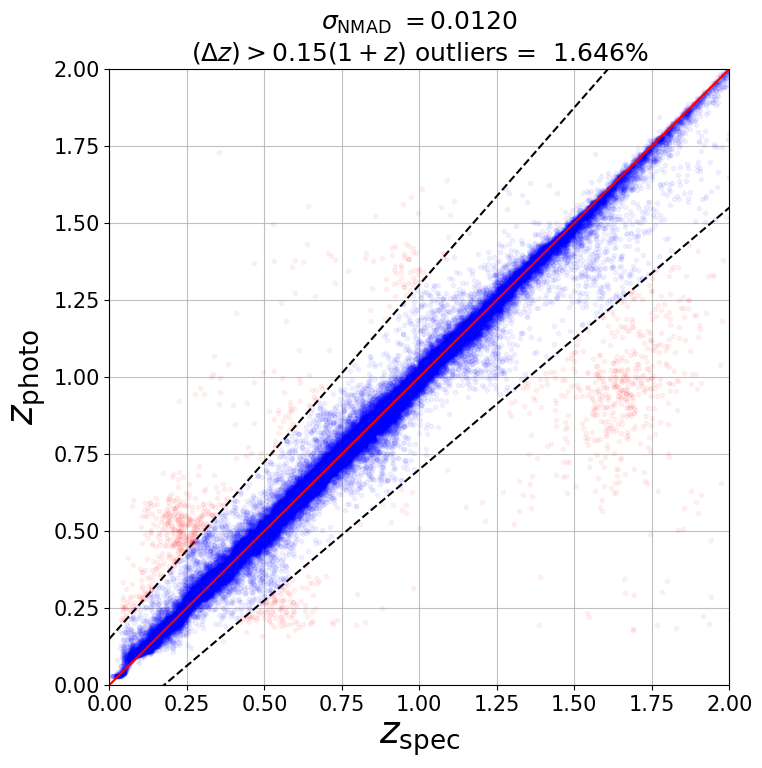

In [39]:
spec = data['redshift']
phot = fz_medians_qp_flexzboost.flatten()
plot_and_stats(spec, phot)